## PDHG TV Applied to Golden Angle Data

This notebook showcases PDHG-TV applied to golden angle data with 25% of the number of projections as an equidistant scan.

In [ ]:
import os
from matplotlib import pyplot as plt

from cil.utilities.display import show2D
from cil.processors import Slicer
from cil.plugins.astra import ProjectionOperator
from cil.optimisation.functions import IndicatorBox
from cil.optimisation.utilities.callbacks import ProgressCallback, EarlyStoppingObjectiveValue

from cil.optimisation.functions import LeastSquares
from cil.optimisation.algorithms import FISTA

from data_io.io import read_mantid_imaging_data
from recon.weighted_fbp import run_weighted_fbp_parallel
from utils.lego_man import calculate_metrics, make_bar_plots
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.utilities.display import show1D
from utils.pdhg import setup_explicit_TV
from cil.optimisation.algorithms import PDHG

import numpy as np
from cil.utilities.display import show1D
from cil.optimisation.operators import GradientOperator

## Data

This notebook uses a dataset of a lego man imaged at IMAT. The lego man is inside a lead container.

The same sample was imaged twice:

1. Equidistant protocol: with angles incrementally increased by the same amount and rotated through a total of 360 degrees.

2. Golden ratio protocol: angles increased by an amount determined by the golden ratio, across 180 degrees.

You will need to download the dataset `preprocessed_data.zip` from https://zenodo.org/records/17814677:

    https://zenodo.org/records/17814677/files/preprocessed_data.zip

Please update the filepath below:

In [10]:
base_path = "/home/lhe97136/Data/Lego GR Investigation/Data for Release/preprocessed_data/"
gr_full = read_mantid_imaging_data(os.path.join(base_path, "Golden_Ratio"), pixel_size=100*10**-4)
equi_full = read_mantid_imaging_data(os.path.join(base_path, "Equidistant"), pixel_size=100*10**-4)

In [11]:
equi_full_slice = equi_full.get_slice(vertical=317)
equi_full_slice.reorder('astra')
equi_full_recon = run_weighted_fbp_parallel(equi_full_slice)

/home/lhe97136/CIL-IMAT-Correct/IMAT-Demos/recon/weighted_fbp.py:114: UserWarning: Because max_gap was None, it has been set to double the mean of all gaps between angles: 0.7860 degree
  return _calculate_angular_sampling_weights(data, 180, max_gap, wedge_behaviour)


Make slices:

In [12]:
gr_scales = [0.25]
gr_slices = {gr_scale: Slicer(roi={'angle': (0, 457 * gr_scale), 'vertical': (317, 318)})(gr_full) for gr_scale in gr_scales}
gr_slices_fbp = {gr_scale: run_weighted_fbp_parallel(gr_slice) for gr_scale, gr_slice in gr_slices.items()}

### Setup the PDHG-TV algorithm


We use PDHG to solve:
$$
u^{*} =\underset{u}{\operatorname{argmin}} \frac{1}{2} \| \mathcal{A} u - g\|^{2} + \alpha\,\mathrm{TV}(u).
$$

Which has a data-fidelity term, plus a regularisation term (TV).

TV (Total Variation) is a regulariser which enforces smooth regions with sharp boundaries. This seems ideal for our lego man sample, where we should have smooth regions of lead and lego.

Below set up the PDHG Algorithm with Total Variation Regularisation and a non-negativity constraint.

We set it up with a range of alpha values. Alpha controls the strength of regularistation applied.

Note: to begin with we performed a wider sweep of alpha values:
[1e-6, 1e-4, 1e-2, 1] to get an idea of where to do a finer sweep of alphas.


In [38]:
alphas=[2e-5, 4e-5,8e-5, 1e-4]

PDHG_nn_algos = {alpha: None for alpha in alphas}
for alpha in alphas:
    ad = gr_slices[0.25]
    ag = ad.geometry
    ig = ag.get_ImageGeometry()
    A = ProjectionOperator(ig, ag, device="gpu")

    K, F = setup_explicit_TV(A, ad, omega=1, alpha=alpha)
    normK = K.norm()
    sigma = 1 # in CIL is 1/normK by default
    tau = 1 / (sigma * normK**2) # in CIL is 1/normK by default
    G = IndicatorBox(lower=0)

    myPDHG_explicit_NN = PDHG(f=F,g=G,
            sigma = sigma,
            tau=tau, 
            operator=K, 
            update_objective_interval = 10)
    PDHG_nn_algos[alpha]=myPDHG_explicit_NN

The above uses the values of sigma and tau which are used in Mantid Imaging.

Unlike SIRT, PDHG-TV does not exhibit semi-convergence. Therefore we usually want to run the algorithm until it has converged. We could measure this by looking at the change in objective value and stopping when it is small e.g. 1e-5 or 1e-6.

However, outside of this notebook we found that the algorithm still hadn't converged after 50,000 iterations!

Here we take a look at whether adjusting sigma or tau, which control the stepsizes for the primal and dual in PDHG could potentially speed up the convergence.
We will run 100 iterations with different values of the step sizes and see which step size results in the lowest objective value as this will indicate the one converging fastest.

First we print the result with the default tau and sigma used in Mantid Imaging:

In [39]:
algo = PDHG_nn_algos[alphas[-1]]
algo.run(100, verbose=1)
print("Objective at 100 iterations when using M.I. default sigma and tau: ", algo.get_last_objective())


  0%|          | 0/100 [00:00<?, ?it/s]

Objective at 100 iterations when using M.I. default sigma and tau:  58.17719210020626


In [40]:
gs = [1e-3, 3e-3, 1e-2,2e-2,2.5e-2, 3e-2, 1e-1, 3e-1]
obj_100 = []
alpha = alphas[-1]
norm_sol = gr_slices_fbp[0.25].norm()
for g in gs:
    gamma = norm_sol * g
    sigma   = gamma / (normK)
    tau = (4/3) / (gamma * normK)

    algo = PDHG(f = F, g = G, operator = K, 
                update_objective_interval = 10, 
                  sigma = sigma, tau=tau)
    algo.run(100, verbose=1)
    obj_100.append(algo.get_last_objective())

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

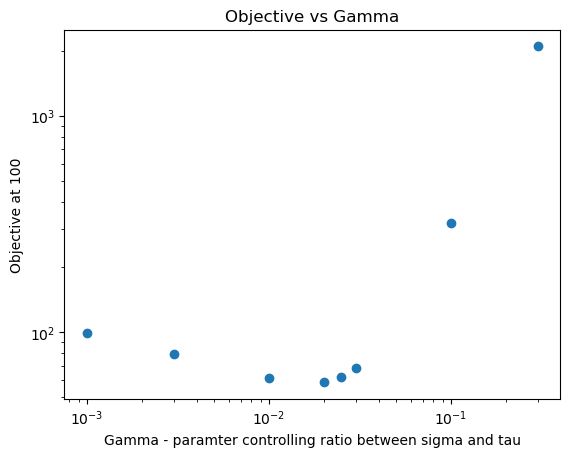

In [41]:
plt.loglog(gs, obj_100, marker='o', linestyle='')

plt.xlabel('Gamma - paramter controlling ratio between sigma and tau')
plt.ylabel('Objective at 100')
plt.title('Objective vs Gamma')
plt.show()

From the graph you can see that if you get the ratio wrong it could make the objective value much higher after 100 iterations, meaning it would take much longer to converge.

In [42]:
print("Minimum objective at 100 iterations: ", min(obj_100))

Minimum objective at 100 iterations:  58.56464370997452


The minimum objective after 100 iters when we tried out different ratios between sigma and tau is not much smaller than that with the mantid Imaging default settings, so it does not seem worth running again with these different parameters - it would still take a very long time to converge.

So we'll proceed and find a different method to choose when to stop... Well run some iterations, look at the results, then come back to discussing number of iterations at the end.

For each value of alpha we run 5000 iterations (note this will take quite some time ~10min):

In [43]:
iteration_nums = 5000
for alpha, pdhg in PDHG_nn_algos.items():
    pdhg.run(iteration_nums)

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  2%|1         | 101/5100 [00:00<?, ?it/s]

First we'll look at a ROI where we can see both the lego man head and the lead container.
Then we'll zoom in on separate ROIs of the head and lead.

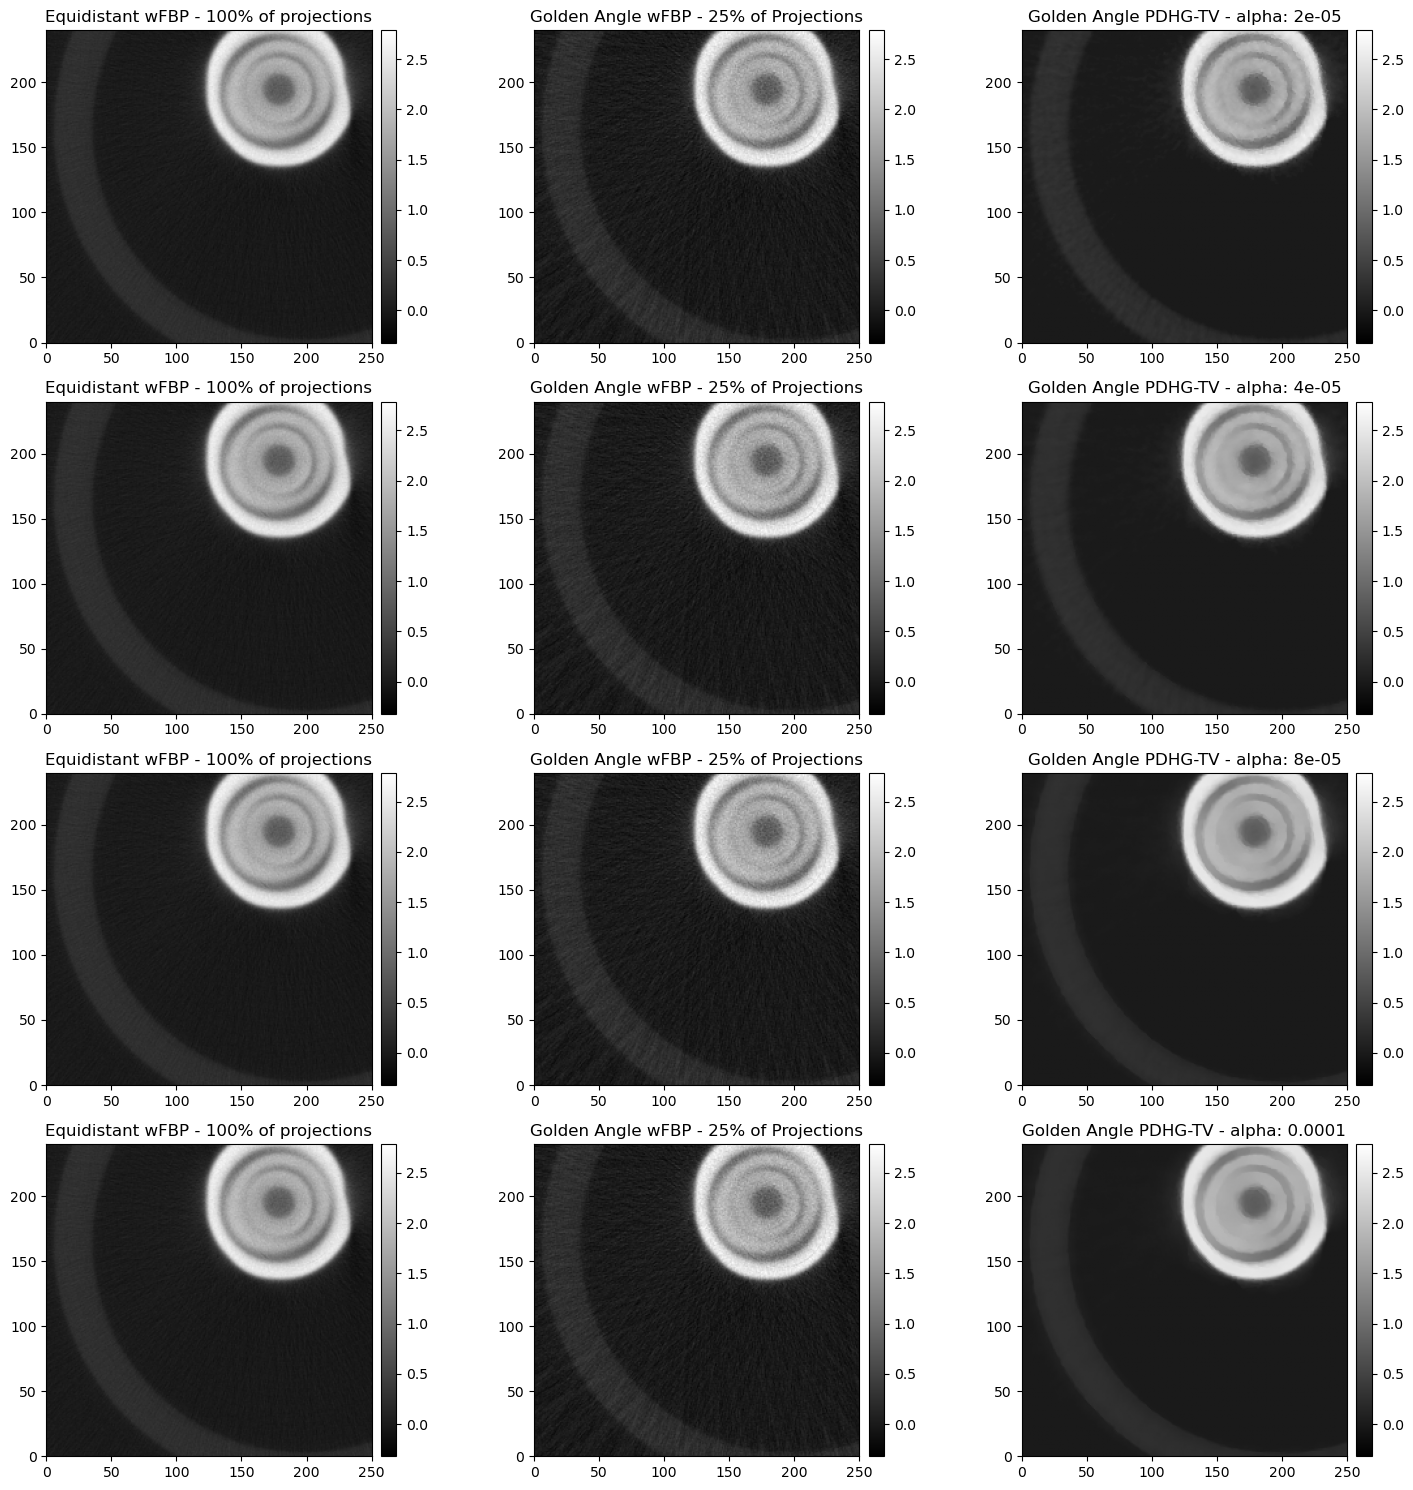

In [44]:
gr_scale=0.25
PDHG_titles = [f"Golden Angle PDHG-TV - alpha: {alpha}" for alpha in alphas]
PDHG_results = [PDHG_nn_algos[alpha].solution for alpha in alphas]
fbp_titles = [f"Golden Angle wFBP - {gr_scale*100:.0f}% of Projections" for alpha in alphas]
fbp_results = [gr_slices_fbp[gr_scale]]*len(alphas)

images = []
titles = []
zoomed_equi_recon = equi_full_recon
for alpha, PDHG_img, PDHG_title, fbp_img, fbp_title in zip(alphas, PDHG_results, PDHG_titles, fbp_results, fbp_titles):
    images.extend([zoomed_equi_recon,fbp_img, PDHG_img])
    titles.extend([f"Equidistant wFBP - 100% of projections", fbp_title, PDHG_title])

vmin = min(img.min() for img in images)
vmax = max(img.max() for img in images)

show2D([x.array[110:350, 100:350] for x in images], title=titles, cmap='gray', fix_range=(vmin, vmax), num_cols=3)

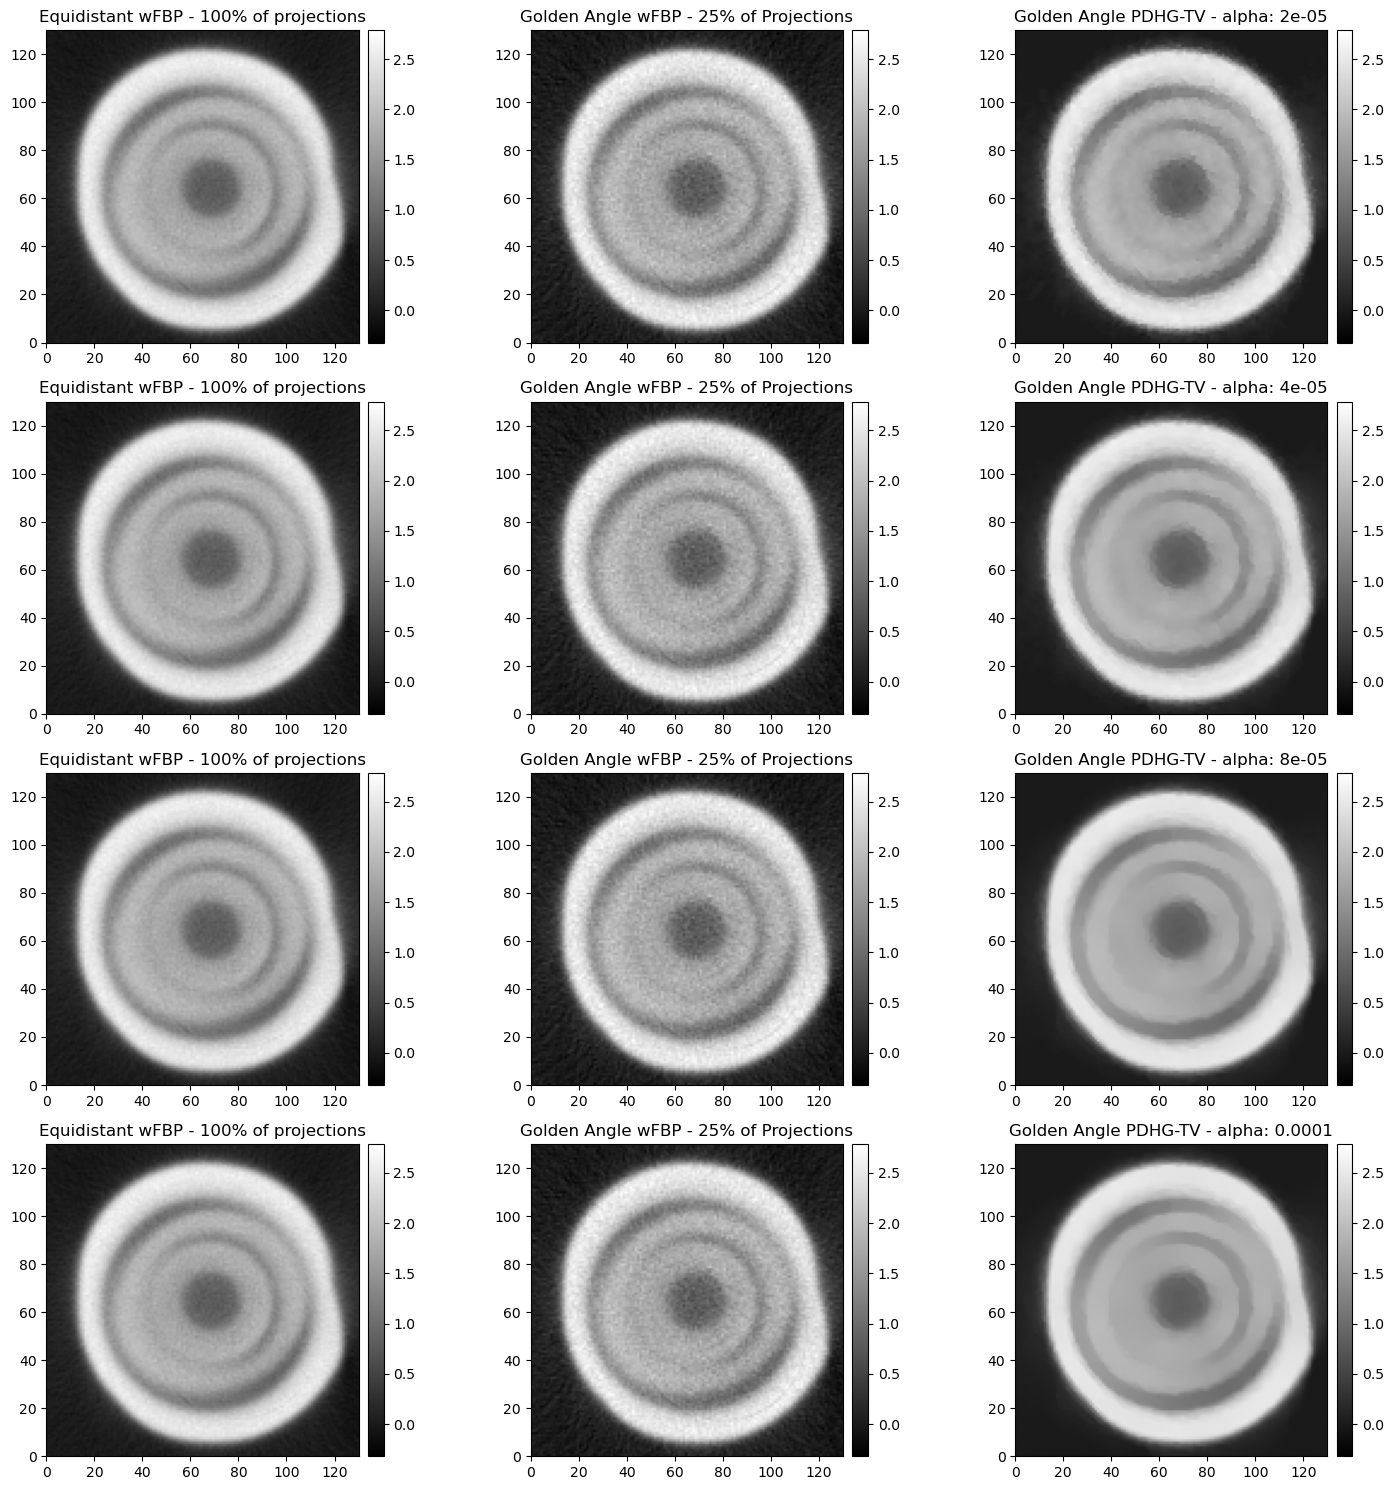

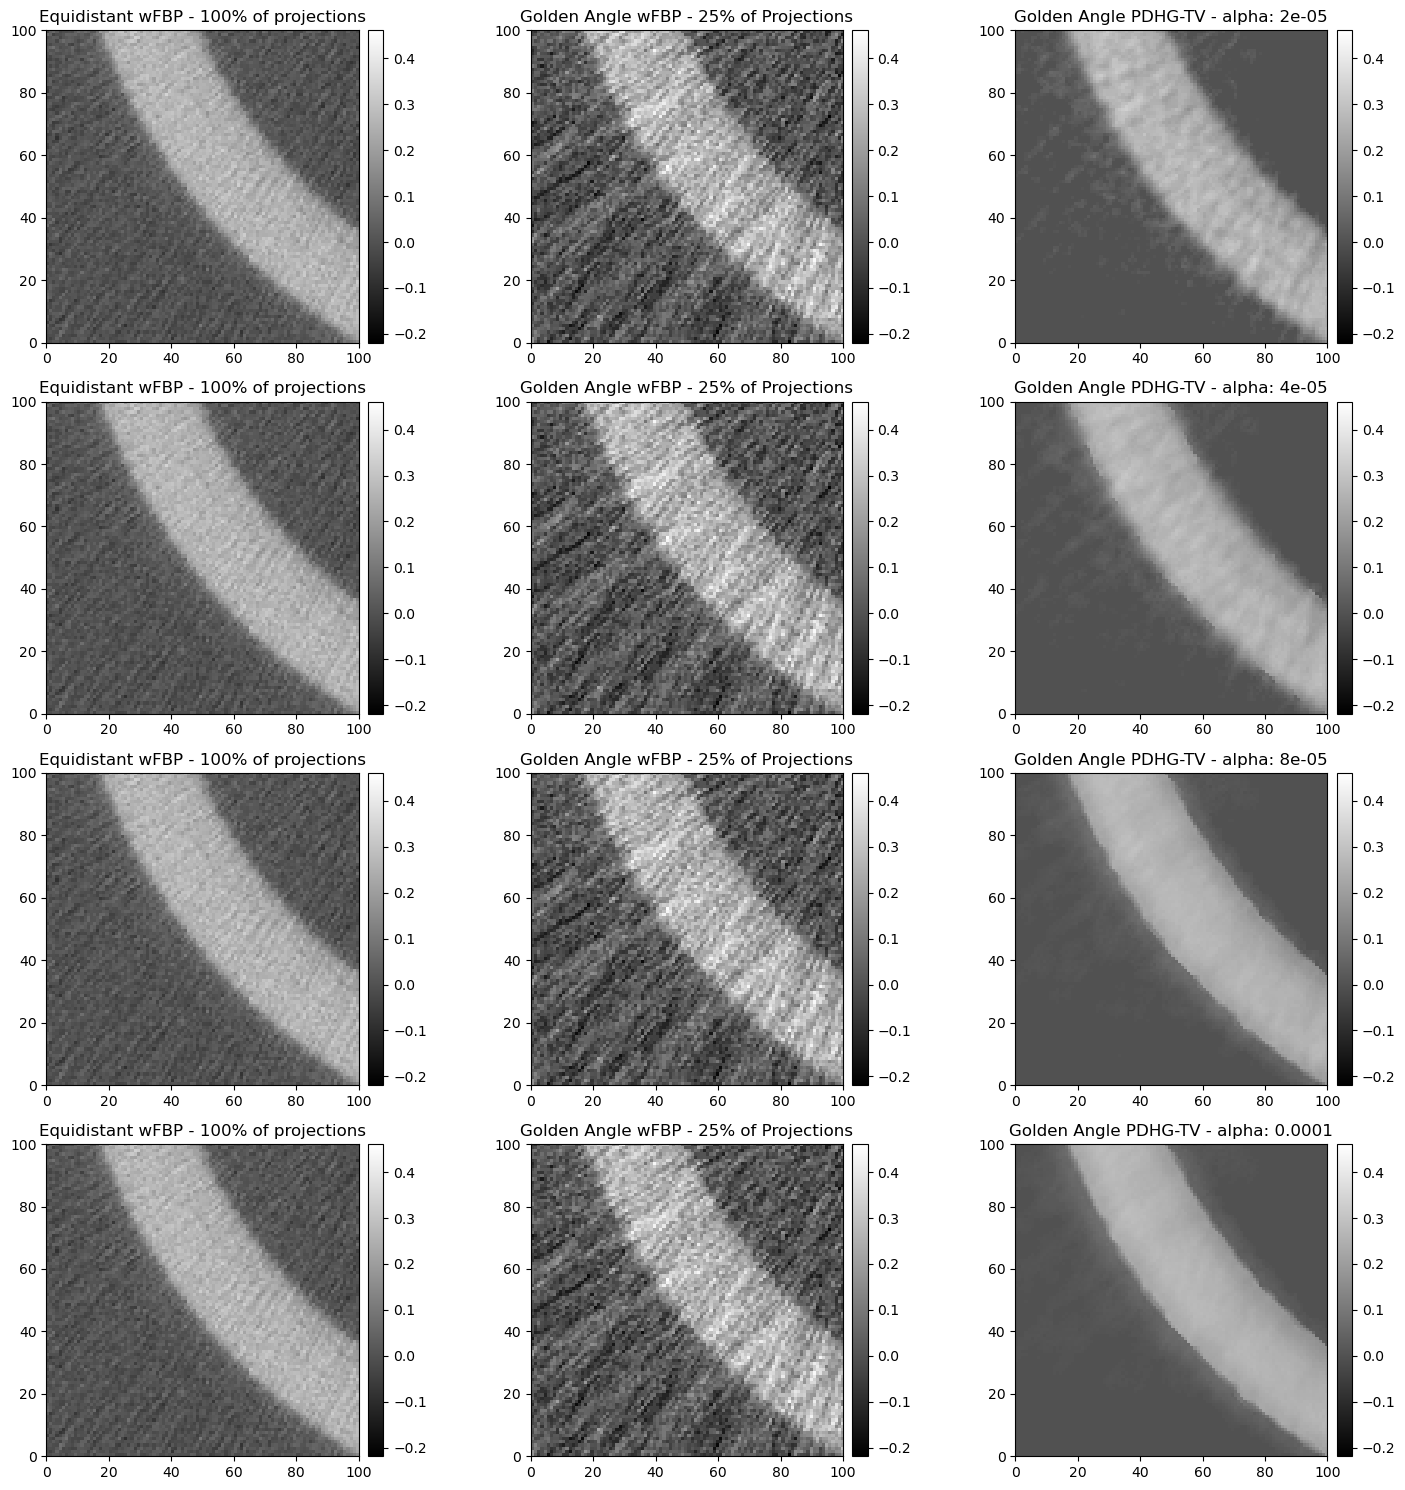

In [45]:
show2D([x.array[240:370, 210:340] for x in images], title=titles, cmap='gray', fix_range=(vmin, vmax), num_cols=3)

data_lead = [x.array[110:210, 100:200] for x in images]
mn = min(x.min() for x in data_lead)
mx = max(x.max() for x in data_lead)
show2D(data_lead, title=titles, cmap='gray', fix_range=(mn, mx), num_cols=3)

Lets look at the line profiles. Here we only compare to the Equidistant FBP, not the wFBP of the 25% Golden Angle. This is because we know from notebook 01 that the wFBP of the 25% Golden Angle is much noiser and we want to be able to see the PDHG results more clearly:

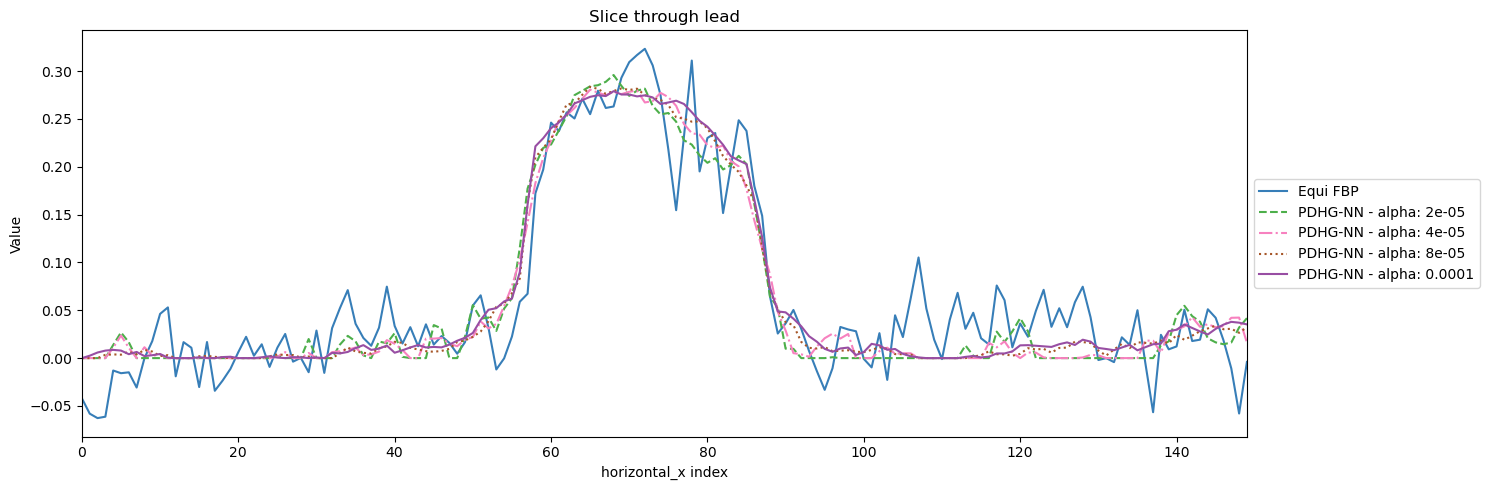

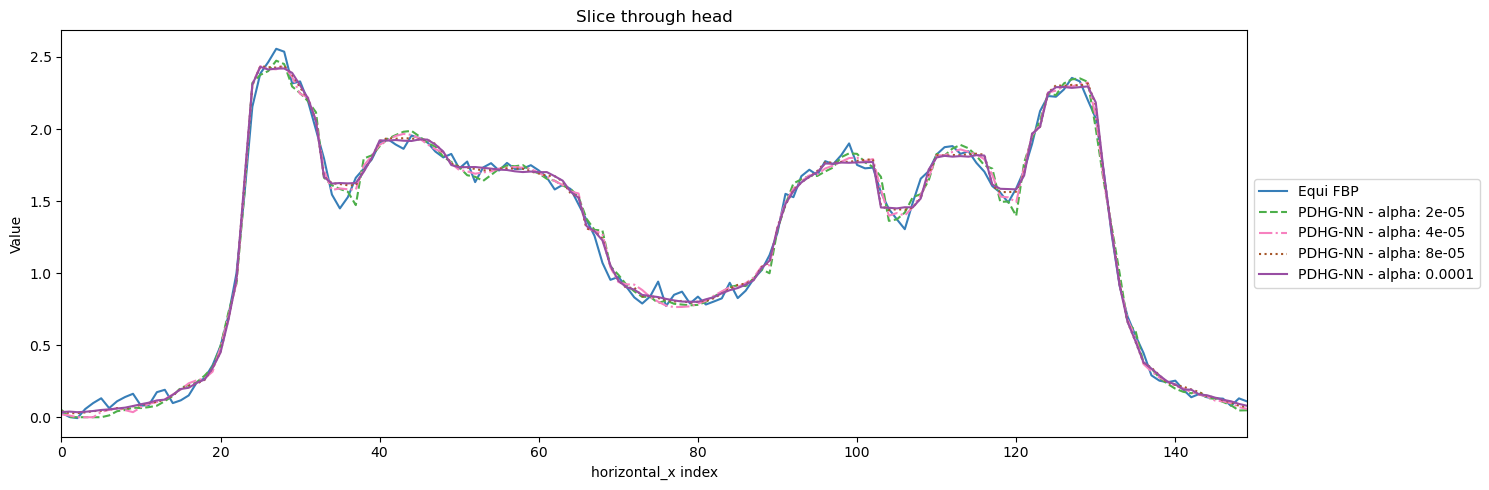

In [46]:
show1d_slicer_lead = Slicer(roi={'horizontal_x':(50,200)})
show1d_slicer_head = Slicer(roi={'horizontal_x':(200,350)})


PDHG_results_list = [gr_slices_fbp[gr_scale]] + [PDHG_nn_algos[alpha].solution for alpha in alphas]
_titles= ['Equi FBP', 'G.A 25% wFBP'] + [f"PDHG-NN - alpha: {alpha}" for alpha in alphas]

data = [equi_full_recon] + PDHG_results_list
colors = ['#377eb8', '#4daf4a',
                    '#f781bf', '#a65628', '#984ea3',
                    '#999999', '#e41a1c', '#dede00']
show1D([show1d_slicer_lead(x) for x in [data[0]]+ data[2:]], slice_list=[('horizontal_y', 300)], dataset_labels=[_titles[0]]+ _titles[2:], title="Slice through lead", size=(15,5), line_colours=colors)
show1D([show1d_slicer_head(x) for x in [data[0]]+ data[2:]], slice_list=[('horizontal_y', 300)], dataset_labels=[_titles[0]]+ _titles[2:], title="Slice through head", size=(15,5), line_colours=colors)



We see that with the highest value of alpha the lead, and the boundary between it and the air is looking great, but we see too much smoothing across the head - the air gaps have material placed inside them. This means we've over-regularised.
Our choice of alpha needs to be a comprimise.

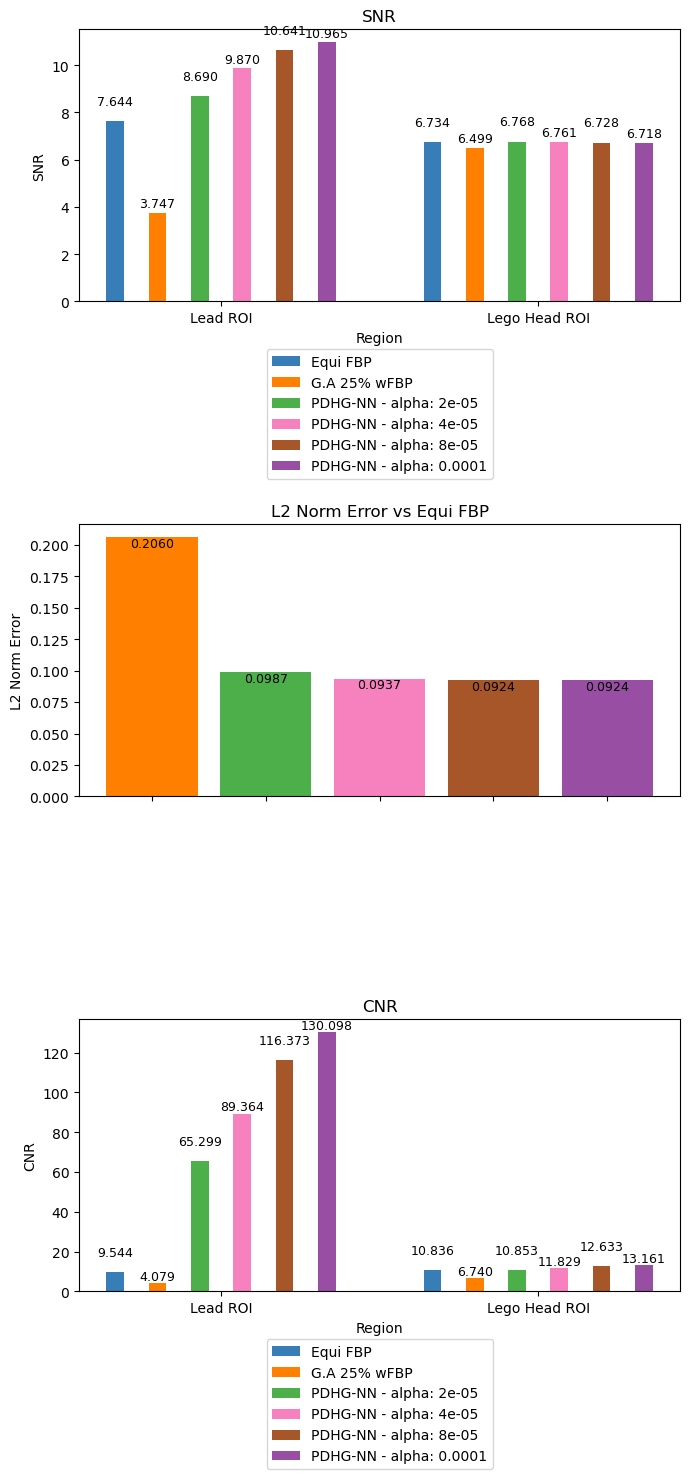

In [47]:

l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner  = calculate_metrics(equi_full_recon, PDHG_results_list)
make_bar_plots(l2n_values, snr_lead, snr_leg, cnr_values, cnr_values_inner, _titles, orientation='vertical')

Our CNR metric for the lego head looks at the contrast to noise ratio between the inner air region in the head and the lego of the head. From the line profiles and images we see this air region is maintained even with high alpha. Our metics don't capture the loss of air regions between the layers.

Here we choose alpha=4e-5. It maintains the line profile across the lego head the better than the higher alpha values, without keeping too much noise.

Let's go back to looking at the convergence and stopping point.

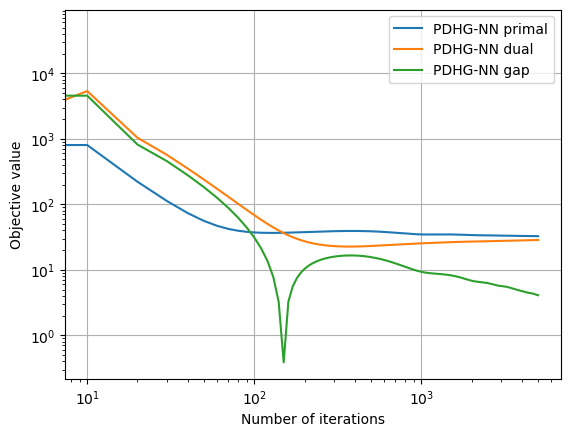

Text(0, 0.5, 'Objective value')

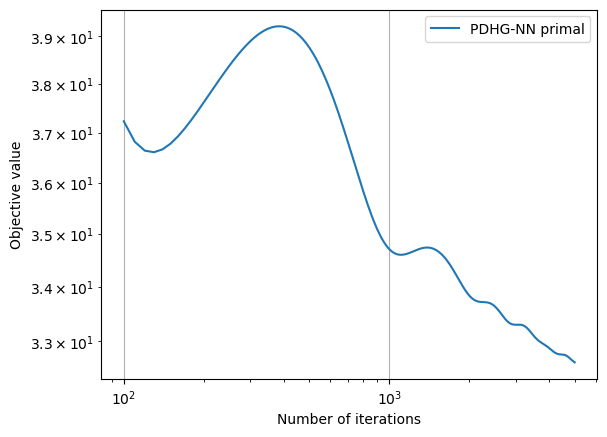

In [51]:
algo = PDHG_nn_algos[4e-5]
plt.figure()
plt.loglog(algo.iterations, algo.objective)
plt.loglog(algo.iterations, algo.dual_objective)
plt.loglog(algo.iterations, np.abs(algo.primal_dual_gap))
plt.legend(['PDHG-NN primal','PDHG-NN dual','PDHG-NN gap'])
plt.grid()
plt.xlabel('Number of iterations')
plt.ylabel('Objective value')
#plt.title(f'PDHG-NN convergence for gr_scale {gr_scale} and alpha {alpha}')
plt.show()
plt.loglog(algo.iterations[10:], algo.objective[10:])
plt.legend(['PDHG-NN primal','PDHG-NN dual','PDHG-NN gap'])
plt.grid()
plt.xlabel('Number of iterations')
plt.ylabel('Objective value')

As we mentioned above, the algorithm has not converged yet.

What we can do is take a look at how much the solution changes between iterations:

In [54]:
diff = []
measure = []

ad = gr_slices[0.25]
ag = ad.geometry
ig = ag.get_ImageGeometry()
A = ProjectionOperator(ig, ag, device="gpu")
K, F = setup_explicit_TV(A, ad, omega=1, alpha=4e-5)
normK = K.norm()
sigma = 1 # in CIL is 1/normK
tau = 1 / (sigma * normK**2) # in CIL is 1/normK
G = IndicatorBox(lower=0)
algo = PDHG(f = F, g = G, operator = K, 
                update_objective_interval = 10, 
                  sigma = sigma, tau=tau)
prev_sol = None
sol = []
for i in range(0,5000):
    algo.run(1, callbacks=[])
    if prev_sol is not None:
        diff.append(algo.solution - prev_sol)
        measure.append((algo.solution - prev_sol).norm()/prev_sol.norm())
    prev_sol = algo.solution.copy()
    sol.append(prev_sol)


Every iteration we have saved the difference between the next and previous solution and calculated the norm of the relative difference.

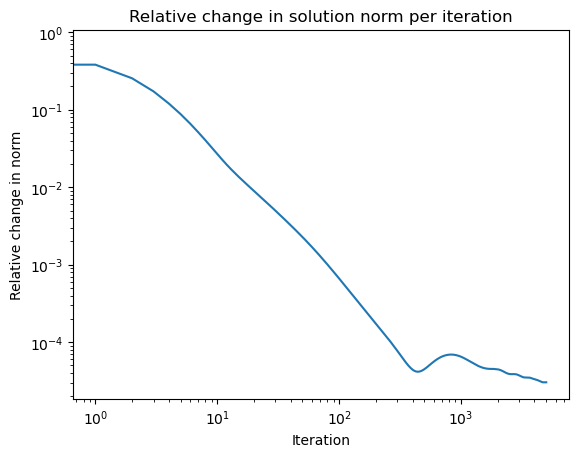

In [55]:
# plot the measure:
plt.loglog(abs(np.array(measure)))
plt.xlabel('Iteration')
plt.ylabel('Relative change in norm')
plt.title('Relative change in solution norm per iteration')
plt.show()

In [59]:
print("After 5000 iterations the relative change in solution norm per iteration: ", measure[-1])
print(f"After {np.where(np.array(measure) < 5e-5)[0][0]} iterations the relative change in solution norm per iteration is less than 0.005%")

After 5000 iterations the relative change in solution norm per iteration:  3.0311021e-05
After 370 iterations the relative change in solution norm per iteration is less than 0.005%


This seems like a pretty small change, let's take a look:

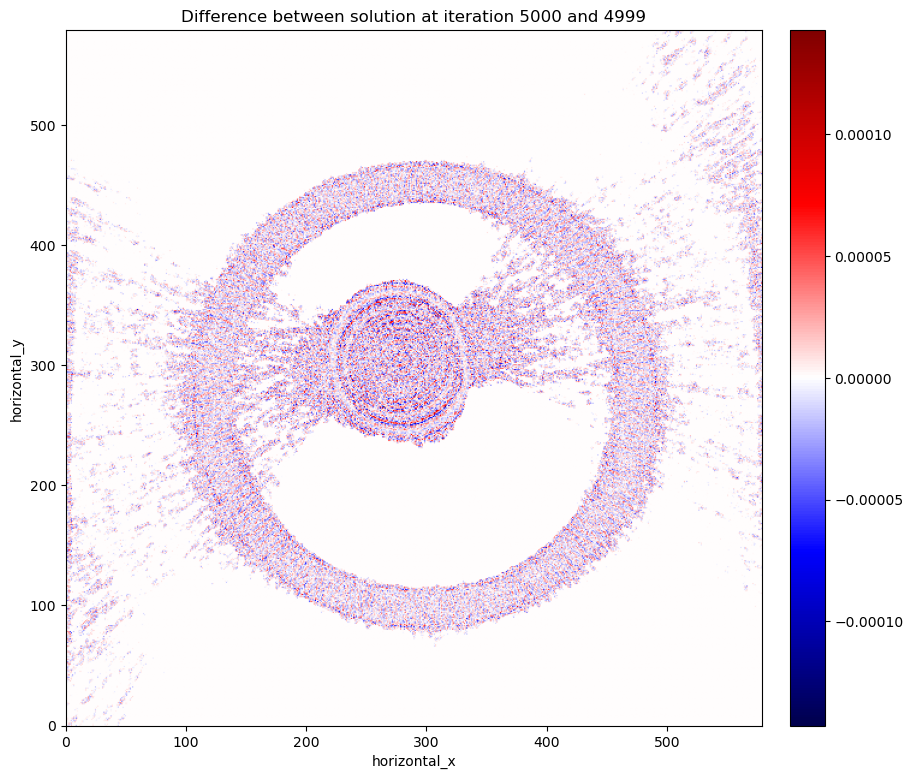

In [62]:
show2D([diff[-1]], cmap='seismic', title='Difference between solution at iteration 5000 and 4999', fix_range=(-diff[-1].abs().max(), diff[-1].abs().max()))


Ideally we'd want to run an algorithm to convergence, but at least we have stopped when the solutions do not change by a lot per iteration.

Note: One reason for PDHG not converging could be sizes of the norm of the projection operator and the norm of the gradient operator. It's theorised they should be close to 1. Let's print ours:

In [ ]:
print("Projection Operator norm: " , A.norm())
print("Gradient Operator norm: ", GradientOperator(A.domain).norm())

Projection Operator norm:  2.5123599
Gradient Operator norm:  282.842712474619


An extension could be to rescale the operators and see if it results in faster convergence.